In [1]:
import yfinance as yf
import torch 
import torch.nn as nn

In [2]:
data = yf.download('AAPL', '2018-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
data.columns = data.columns.droplevel(1)

In [4]:
data

Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.267067,40.276419,39.565794,39.776178,102223600
2018-01-03,40.260059,40.802379,40.196947,40.330187,118071600
2018-01-04,40.447071,40.549925,40.225002,40.332529,89738400
2018-01-05,40.907578,40.994067,40.451751,40.542916,94640000
2018-01-08,40.755638,41.050171,40.657457,40.755638,82271200
...,...,...,...,...,...
2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200


In [5]:
import numpy as np
import pandas as pd

def add_features(df):
    df = df.copy()

    df["Return"] = df["Close"].pct_change()
    df["LogReturn"] = np.log(df["Close"] / df["Close"].shift(1))

    df["HighLowPct"] = (df["High"] - df["Low"]) / df["Close"]
    df["OpenClosePct"] = (df["Close"] - df["Open"]) / df["Open"]

    df["MA5"] = df["Close"].rolling(5).mean()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()

    df["DistMA20"] = df["Close"] / df["MA20"] - 1
    df["DistMA50"] = df["Close"] / df["MA50"] - 1

    df["Volatility20"] = df["Return"].rolling(20).std()

    df["VolumeChange"] = df["Volume"].pct_change()
    df["VolumeMA20"] = df["Volume"].rolling(20).mean()

    delta = df["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + rs))

    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()

    df["MACD"] = ema12 - ema26
    df["MACDSignal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["MACDHist"] = df["MACD"] - df["MACDSignal"]

    df = df.dropna()

    return df

In [6]:
data = add_features(data)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [8]:
train_data = data[:-300]
test_data = data[-300:]


In [9]:
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

In [10]:
train_X = []
train_y = []

In [11]:
test_X = []
test_y = []

In [12]:
test_data[0]

array([ 1.24698772,  1.26983018,  1.25448148,  1.27370144, -0.81521689,
        1.16919363,  1.16545868,  0.27656941, -0.51550563,  1.1374551 ,
        1.23439489,  1.54741809, -0.01273259, -1.23511339,  3.97355482,
       -0.13683097, -0.44464378, -0.74778022, -2.54850364, -3.36703948,
        1.79794406])

In [13]:
i =0

In [14]:
try:
    while True:
        train_X.append(train_data[i:60+i])
        train_y.append(train_data[60+i][3])
        i+=1

except:
    pass


i=0

try:
    while True:
        test_X.append(test_data[i:60+i])
        test_y.append(test_data[60+i][3])
        i+=1

except:
    pass



In [15]:
train_X = train_X[:-1]
test_X = test_X[:-1]

In [16]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

In [17]:
class StockDataset(Dataset):
    def __init__(self,X, y):
        self.X = torch.tensor(X, dtype= torch.float32)
        self.y = torch.tensor(y, dtype= torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [18]:
train_ds  = StockDataset(train_X, train_y)

/tmp/ipykernel_24012/1768878257.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.X = torch.tensor(X, dtype= torch.float32)


In [19]:
from transformer import build_encoder

In [20]:
class StockEmbeddings(nn.Module):
    def __init__(self, num_features, d_model):
        super().__init__()
        self.layer  = nn.Linear(num_features, d_model)

    def forward(self, X):
        return self.layer(X)
    

class OutputLayer(nn.Module):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.layer1 = nn.Linear(seq_len*d_model, 1024)
        self.layer2 = nn.Linear(1024, 512)
        self.layer3 = nn.Linear(512,1)
        self.relu = nn.ReLU()

    def forward(self, X):
        return self.layer3(self.relu(self.layer2(self.relu((self.layer1(X))))))

In [21]:
embeddings  = StockEmbeddings(21, 64).to('cuda')
outputlayer = OutputLayer(60, 64).to('cuda')

In [22]:
device = torch.device('cuda')

In [23]:
encoder = build_encoder(60, 64, 4, 2, 256, 0.1).to(device)

In [24]:
from transformer import PositionalEncoding

In [25]:
pos_encoder = PositionalEncoding(64, 60, 0.1).to(device)

In [26]:
dataloader = DataLoader(train_ds, 32, shuffle= True)

In [27]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(list(encoder.parameters() ) + list(embeddings.parameters()) + list(outputlayer.parameters()), lr = 1e-5)

In [28]:
from tqdm import tqdm, trange
losses = []

In [29]:
for i in trange(50):
    total_loss = 0

    for X, y in dataloader:
        optimizer.zero_grad()
        X, y = X.to(device), y.to(device)
        out = embeddings(X)
        out = pos_encoder(out)
        out = encoder(out, None)
        out = out.reshape(out.shape[0], -1)
        out = outputlayer(out)
        out = out.reshape(y.shape)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

        total_loss+= loss.item()
    losses.append(total_loss/ len(dataloader))
    print(f"Loss = {total_loss/ len(dataloader)}")
    

  2%|▏         | 1/50 [00:00<00:40,  1.20it/s]

Loss = 0.20897428563761491


  4%|▍         | 2/50 [00:01<00:24,  1.94it/s]

Loss = 0.019614700779870705


  6%|▌         | 3/50 [00:01<00:19,  2.45it/s]

...

Loss = 0.0015851300634461007


 98%|█████████▊| 49/50 [00:13<00:00,  4.01it/s]

Loss = 0.0016524693206452798


100%|██████████| 50/50 [00:14<00:00,  3.56it/s]

Loss = 0.0015659392466423688


In [30]:
test_ds = StockDataset(test_X, test_y)

In [31]:
test_loader = DataLoader(test_ds, 100000)

In [32]:
encoder.eval()

with torch.no_grad():
     for X, y in test_loader:
        optimizer.zero_grad()
        X, y = X.to(device), y.to(device)
        out = embeddings(X)
        out = pos_encoder(out)
        out = encoder(out, None)
        out = out.reshape(out.shape[0], -1)
        out = outputlayer(out)
        out = out.reshape(y.shape)
    

In [33]:
import numpy as np

pred = np.array(out.cpu(), dtype=np.float32)

dummy = np.zeros((len(pred), 21))

dummy[:, 3] = pred

inverse = scaler.inverse_transform(dummy)

predicted = inverse[:, 3]

/tmp/ipykernel_24012/1982205466.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pred = np.array(out.cpu(), dtype=np.float32)


In [34]:

pred = np.array(test_y, dtype=np.float32)

dummy = np.zeros((len(pred), 21))

dummy[:, 3] = pred

inverse = scaler.inverse_transform(dummy)

original_values = inverse[:, 3]

In [35]:
import matplotlib.pyplot as plt

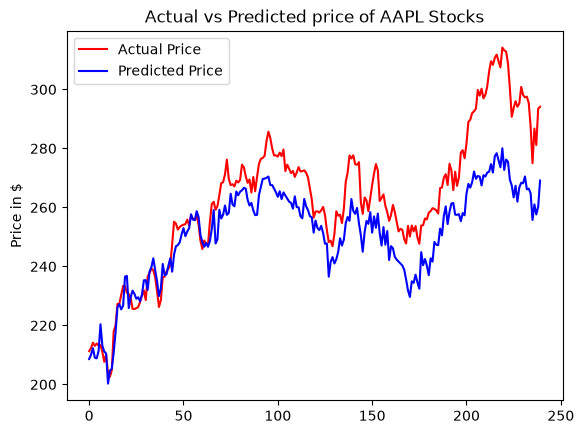

In [38]:
plt.plot(original_values, color = 'red', label = "Actual Price")
plt.plot(predicted, color = 'blue', label = "Predicted Price")
plt.ylabel("Price in $")
plt.title("Actual vs Predicted price of AAPL Stocks")
plt.legend(loc='upper left')
plt.savefig("apple_predictions.png")

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(original_values, predicted)
rmse = np.sqrt(mean_squared_error(original_values, predicted))
r2 = r2_score(original_values, predicted)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 12.236479620453979
RMSE: 15.401205804366079
R²: 0.5813361477825534
